# ABS Dual Income: Couple Families (6224.0.55.001)

**Stage one** of the individual-to-household income analysis.

Thesis: the multiple linking individual income to household income has risen, driven by the shift to dual-income couple families. This notebook surfaces that shift directly from the ABS *Labour Force Status of Families* collection (annual, June reference, back to 1979), classifying couple families by whether *both*, *at least one*, or *neither* partner is employed.

Source: ABS 6224.0.55.001, Table 3 (Labour force characteristics of families). This collection is a data cube, not a Time Series Directory series, so it is fetched directly from the release landing page rather than via `read_abs_cat`.

## Python set up

In [1]:
# system imports
from io import BytesIO

# analysis imports
import pandas as pd
import mgplot as mg

# local imports
import common

In [2]:
# pandas display
pd.options.display.max_rows = 999999
pd.options.display.max_columns = 100

# release configuration -- bump these when a new June release lands
CAT = "6224.0.55.001"
MONTH, YEAR = "jun", "2025"
TABLE, SHEET = "62240_Table03", "Data 3.1"  # labour force characteristics
TABLE1, SHEET1 = "62240_Table01", "Data 1.1"  # family types
TABLEH, SHEETH = "62240_TableH1", "Data H.1"  # households (experimental)

# chart configuration
SHOW = True
FILE_TYPE = "png"
CHART_DIR = "./CHARTS/Dual Income - Families/"
mg.set_chart_dir(CHART_DIR)
mg.clear_chart_dir()

# footers
source = f"ABS {CAT}, {MONTH.title()} {YEAR}"
LFOOTER = "Australia. Couple families, with and without children. "

## Fetch data

In [3]:
def get_table3() -> pd.DataFrame:
    """Fetch Table 3 (Labour force characteristics of families) data cube."""
    url = (
        "https://www.abs.gov.au/statistics/labour/employment-and-unemployment/"
        f"labour-force-status-families/{MONTH}-{YEAR}/{TABLE}.xlsx"
    )
    raw = common.request_get(url)
    df = pd.read_excel(BytesIO(raw), sheet_name=SHEET, header=6)
    return df


RAW = get_table3()
assert not RAW.empty, "Table 3 fetch returned no rows"

## Tidy and reshape

Keep Australia-level *Couple families - Summary* rows, clean the leading-space labels, and collapse to an annual wide frame of counts ('000). The cube is annual (June) except 2019-2022, which carry extra quarters; an annual mean reconciles them for a slow-moving share.

In [4]:
def tidy(df: pd.DataFrame) -> pd.DataFrame:
    """Australia couple-family labour-force-status counts ('000), annual wide."""
    df = df.rename(columns={df.columns[0]: "Month", df.columns[4]: "value"})
    keep = ["Month", "State or Territory", "Family type", "Labour force status", "value"]
    df = df[keep].copy()
    df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
    df = df.dropna(subset=["Month"])
    for col in ["State or Territory", "Family type", "Labour force status"]:
        df[col] = df[col].str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    couple = df[
        (df["State or Territory"] == "Australia")
        & (df["Family type"] == "Couple families - Summary")
    ]
    wide = couple.pivot_table(
        index="Month", columns="Labour force status", values="value"
    )
    wide = wide.groupby(wide.index.year).mean()  # collapse extra quarters to annual
    wide.index = pd.PeriodIndex(wide.index, freq="Y")
    return wide


COUPLE = tidy(RAW)
COUPLE.tail()

Labour force status,At least one partner employed,Both partners employed,Couple families,Neither partner employed
Month,,,,
2021,4650.9835,3394.22975,6007.1425,1243.10475
2022,4719.1140,3467.14850,6077.9565,1245.35050
2023,4811.5420,3598.89700,6218.5310,1268.23800
2024,4855.9150,3643.26000,6217.5050,1223.48200
2025,4983.5340,3735.09700,6379.2450,1257.35100


## Dual-income metrics

- **Both employed (%)** = both-employed couple families / all couple families.
- **Earners per couple family** = average employed partners per couple family = (2 x both + 1 x one-only) / total = (both + at-least-one) / total. This is the individual-to-household earner multiple at the heart of the thesis.

In [5]:
def dual_income_metrics(wide: pd.DataFrame) -> pd.DataFrame:
    """Derive dual-income indicators for couple families."""
    total = wide["Couple families"]
    both = wide["Both partners employed"]
    at_least_one = wide["At least one partner employed"]
    one_only = at_least_one - both
    neither = total - at_least_one

    out = pd.DataFrame(index=wide.index)
    out["Both employed (%)"] = both / total * 100
    out["Earners per couple family"] = (both + at_least_one) / total
    out["One only (%)"] = one_only / total * 100
    out["Neither (%)"] = neither / total * 100
    return out


METRICS = dual_income_metrics(COUPLE)
METRICS.tail()

,Both employed (%),Earners per couple family,One only (%),Neither (%)
Month,,,,
2021,56.503233,1.339275,20.920991,22.575775
2022,57.044642,1.346877,20.598461,22.356897
2023,57.873749,1.352480,19.500506,22.625746
2024,58.596817,1.366975,19.503885,21.899299
2025,58.550769,1.366718,19.570294,21.878937


## Charts

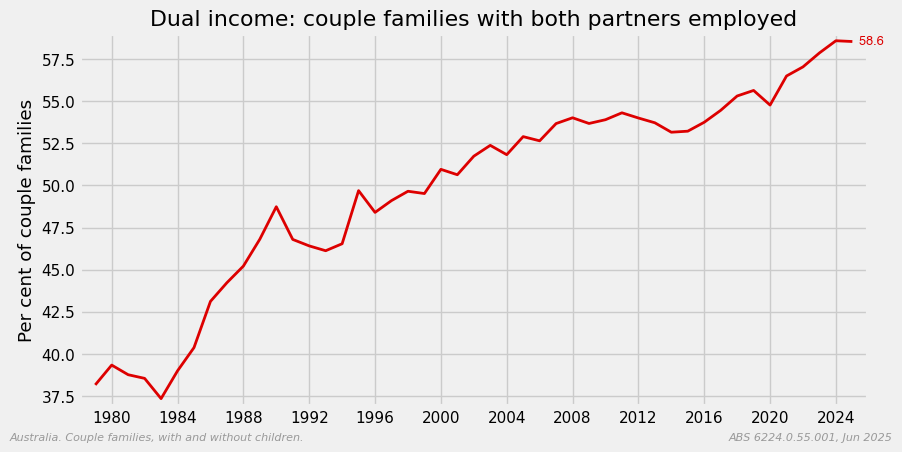

In [6]:
def plot_both_share(metrics: pd.DataFrame) -> None:
    """Headline dual-income chart: both-partners-employed share."""
    mg.line_plot_finalise(
        metrics["Both employed (%)"],
        title="Dual income: couple families with both partners employed",
        ylabel="Per cent of couple families",
        rfooter=source,
        lfooter=LFOOTER,
        annotate=True,
        rounding=1,
        width=2,
        show=SHOW,
        file_type=FILE_TYPE,
    )


plot_both_share(METRICS)

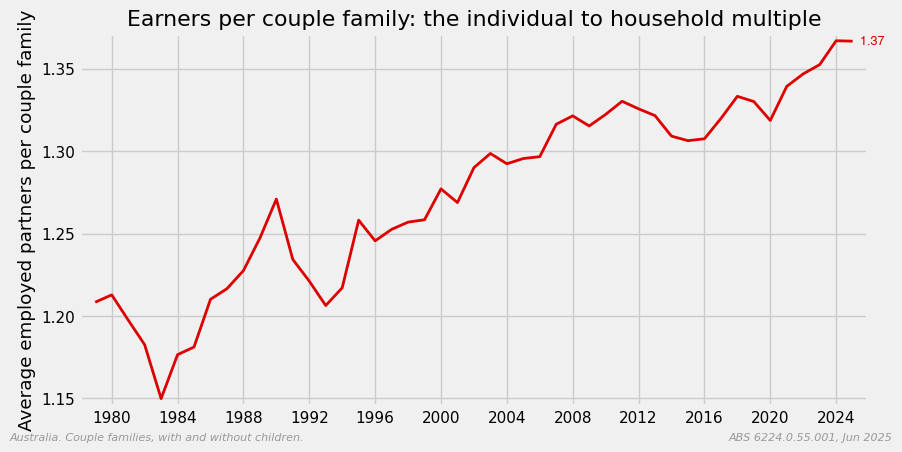

In [7]:
def plot_earners(metrics: pd.DataFrame) -> None:
    """The individual-to-household earner multiple."""
    mg.line_plot_finalise(
        metrics["Earners per couple family"],
        title="Earners per couple family: the individual to household multiple",
        ylabel="Average employed partners per couple family",
        rfooter=source,
        lfooter=LFOOTER,
        annotate=True,
        rounding=2,
        width=2,
        show=SHOW,
        file_type=FILE_TYPE,
    )


plot_earners(METRICS)

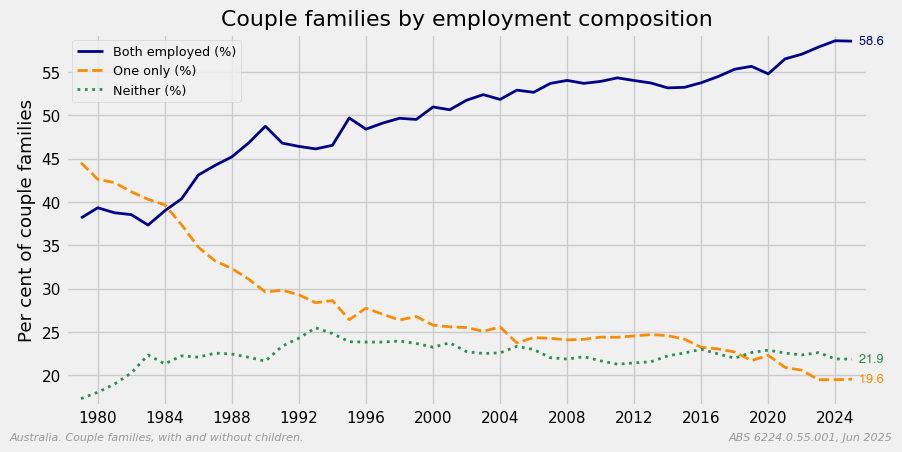

In [8]:
def plot_composition(metrics: pd.DataFrame) -> None:
    """How couple families split across both / one-only / neither employed."""
    comp = metrics[["Both employed (%)", "One only (%)", "Neither (%)"]]
    mg.line_plot_finalise(
        comp,
        title="Couple families by employment composition",
        ylabel="Per cent of couple families",
        rfooter=source,
        lfooter=LFOOTER,
        style=["-", "--", ":"],
        width=[2, 2, 2],
        annotate=True,
        rounding=1,
        legend={"loc": "best", "fontsize": "small"},
        show=SHOW,
        file_type=FILE_TYPE,
    )


plot_composition(METRICS)

## Family-type composition

A companion view: the share of *all* families by type over time -- one-parent ('single'), couple with dependent children, couple with no dependent children, and other families. Built from Table 1 (Family types).

Note: one-parent and 'other' families were not separately reported in this collection before **1994** (earlier years cover couples only), so the composition starts at 1994. 'Dependent children' means dependants aged 0-24; a couple whose only children are 25+ counts as 'no dependent children'.

In [9]:
def get_table1() -> pd.DataFrame:
    """Fetch Table 1 (Family types) data cube."""
    url = (
        "https://www.abs.gov.au/statistics/labour/employment-and-unemployment/"
        f"labour-force-status-families/{MONTH}-{YEAR}/{TABLE1}.xlsx"
    )
    df = pd.read_excel(BytesIO(common.request_get(url)), sheet_name=SHEET1, header=6)
    return df


RAW1 = get_table1()
assert not RAW1.empty, "Table 1 fetch returned no rows"

In [10]:
def family_type_composition(df: pd.DataFrame) -> pd.DataFrame:
    """Share of all families by type (%), annual, from 1994 (full breakdown)."""
    df = df.rename(columns={
        df.columns[0]: "Month", df.columns[2]: "Family type",
        df.columns[3]: "Total_000", df.columns[5]: "Deps_000",
    })
    df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
    df = df.dropna(subset=["Month"])
    df["State or Territory"] = df["State or Territory"].str.strip()
    df["Family type"] = df["Family type"].str.strip()
    for c in ["Total_000", "Deps_000"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    au = df[df["State or Territory"] == "Australia"]

    def grab(ftype: str, col: str = "Total_000") -> pd.Series:
        s = au[au["Family type"] == ftype].set_index("Month")[col]
        s = s.groupby(s.index.year).mean()  # collapse extra quarters to annual
        s.index = pd.PeriodIndex(s.index, freq="Y")
        return s

    total = grab("Total families")
    couple_dep = grab("Couple families", "Deps_000")
    comp = pd.DataFrame({
        "One parent (single)": grab("One parent families"),
        "Couple, dependent children": couple_dep,
        "Couple, no dependent children": grab("Couple families") - couple_dep,
        "Other families": grab("Other families"),
    }).div(total, axis=0) * 100
    # keep only years where all categories are reported (sum ~100%) -> 1994 on
    comp = comp[comp.sum(axis=1).round(0).between(99, 101)]
    return comp


COMPOSITION = family_type_composition(RAW1)
COMPOSITION.tail()

,One parent (single),"Couple, dependent children","Couple, no dependent children",Other families
Month,,,,
2021,15.202107,36.182110,47.061471,1.554305
2022,14.718375,36.534439,47.091900,1.655292
2023,14.642987,35.769222,47.872779,1.715012
2024,15.847816,35.216879,46.918572,2.016733
2025,15.889955,34.759887,47.567292,1.782865


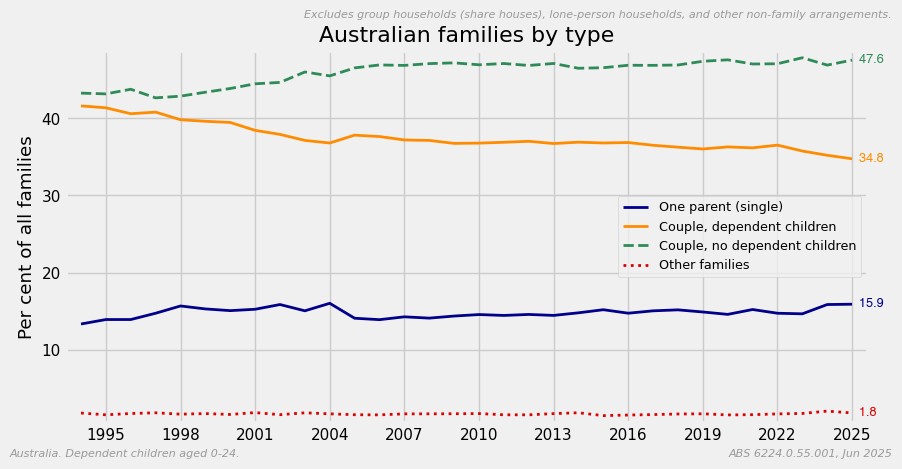

In [11]:
def plot_family_composition(comp: pd.DataFrame) -> None:
    """Share of all families by type over time."""
    mg.line_plot_finalise(
        comp,
        title="Australian families by type",
        ylabel="Per cent of all families",
        rfooter=source,
        lfooter="Australia. Dependent children aged 0-24. ",
        rheader="Excludes group households (share houses), lone-person households, and other non-family arrangements.",
        style=["-", "-", "--", ":"],
        width=2,
        annotate=True,
        rounding=1,
        legend={"loc": "best", "fontsize": "small"},
        show=SHOW,
        file_type=FILE_TYPE,
    )


plot_family_composition(COMPOSITION)

## Household composition

The household-level counterpart, from the experimental Table H1. Unlike the family tables, this *includes* lone-person and group (share) households -- the ~30% of households the family collection excludes. Four mutually exclusive top-level types as a share of all households.

Caveats: experimental estimates, available only from **2005**. The cube is a nested list (family sub-types double-count), so we use only the four top-level types with 'Total households' as the denominator. Note this sheet's header sits one row lower than the family tables (`header=7`).

In [12]:
def get_tableH1() -> pd.DataFrame:
    """Fetch Table H1 (Households, experimental). Header is one row lower."""
    url = (
        "https://www.abs.gov.au/statistics/labour/employment-and-unemployment/"
        f"labour-force-status-families/{MONTH}-{YEAR}/{TABLEH}.xlsx"
    )
    df = pd.read_excel(BytesIO(common.request_get(url)), sheet_name=SHEETH, header=7)
    return df


RAWH = get_tableH1()
assert not RAWH.empty, "Table H1 fetch returned no rows"

In [13]:
def household_composition(df: pd.DataFrame) -> pd.DataFrame:
    """Share of all households by top-level type (%), annual, from 2005."""
    df = df.rename(columns={
        df.columns[0]: "Month", df.columns[1]: "State",
        df.columns[2]: "Jobless status", df.columns[3]: "Household type",
        df.columns[4]: "Households_000",
    })
    df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
    df = df.dropna(subset=["Month"])
    for c in ["State", "Jobless status", "Household type"]:
        df[c] = df[c].str.strip()
    df["Households_000"] = pd.to_numeric(df["Households_000"], errors="coerce")
    au = df[(df["State"] == "Australia") & (df["Jobless status"] == "All households")]

    def grab(htype: str) -> pd.Series:
        s = au[au["Household type"] == htype].set_index("Month")["Households_000"]
        s = s.groupby(s.index.year).mean()  # collapse extra quarters to annual
        s.index = pd.PeriodIndex(s.index, freq="Y")
        return s

    total = grab("Total households")
    comp = pd.DataFrame({
        "One-family households": grab("One family households"),
        "Lone-person households": grab("Lone person households"),
        "Group (share) households": grab("Group households"),
        "Multiple-family households": grab("Multiple family households"),
    }).div(total, axis=0) * 100
    return comp


HH_COMPOSITION = household_composition(RAWH)
HH_COMPOSITION.tail()

,One-family households,Lone-person households,Group (share) households,Multiple-family households
Month,,,,
2021,68.378801,26.433666,2.941777,2.235376
2022,67.962332,26.540615,2.979720,2.073533
2023,67.707812,26.945599,3.417936,1.924052
2024,66.820366,27.225767,3.813049,2.133872
2025,67.651905,27.491388,2.990388,1.857972


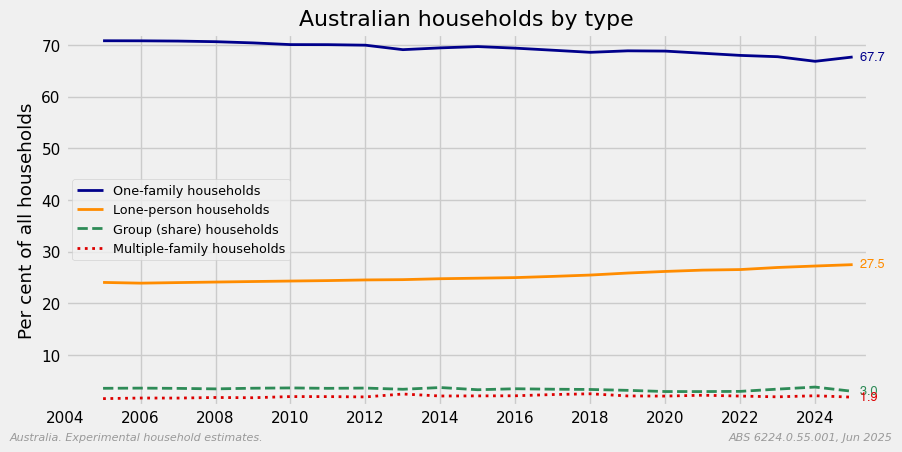

In [14]:
def plot_household_composition(comp: pd.DataFrame) -> None:
    """Share of all households by type over time."""
    mg.line_plot_finalise(
        comp,
        title="Australian households by type",
        ylabel="Per cent of all households",
        rfooter=source,
        lfooter="Australia. Experimental household estimates. ",
        style=["-", "-", "--", ":"],
        width=2,
        annotate=True,
        rounding=1,
        legend={"loc": "best", "fontsize": "small"},
        show=SHOW,
        file_type=FILE_TYPE,
    )


plot_household_composition(HH_COMPOSITION)

## Watermark

In [15]:
%load_ext watermark
%watermark -u -t -d --iversions --watermark --machine --python --conda

Last updated: 2026-06-09 09:27:32

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.14.0

conda environment: n/a

Compiler    : Clang 21.1.4 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

mgplot: 0.2.26
pandas: 3.0.3

Watermark: 2.6.0

